In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
train_df = pd.read_csv(
    "../data/processed/train_features.csv"
)

exclude_cols = [
    "unit",
    "cycle",
    "RUL",
    "setting_1",
    "setting_2",
    "setting_3"
]

feature_cols = [
    col for col in train_df.columns
    if col not in exclude_cols
]

train_df = train_df.sort_values(
    ["unit", "cycle"]
).reset_index(drop=True)

exclude_cols = [
    "unit",
    "cycle",
    "RUL",
    "setting_1",
    "setting_2",
    "setting_3"
]

feature_cols = [
    col for col in train_df.columns
    if col not in exclude_cols
]


units = train_df["unit"].unique()

print("Number of engines:", len(units))


train_units, val_units = train_test_split(
    units,
    test_size=0.2,
    random_state=42
)

train_data = train_df[
    train_df["unit"].isin(train_units)
].copy()

val_data = train_df[
    train_df["unit"].isin(val_units)
].copy()

scaler = StandardScaler()

train_data_scaled = train_data.copy()
val_data_scaled = val_data.copy()

train_data_scaled[feature_cols] = scaler.fit_transform(
    train_data[feature_cols]
)

val_data_scaled[feature_cols] = scaler.transform(
    val_data[feature_cols]
)

joblib.dump(
    scaler,
    "../models/stacked_gru_feature_scaler.joblib"
)


Number of engines: 100


['../models/stacked_gru_feature_scaler.joblib']

In [5]:
sequence_length = 30

def create_sequences(data, feature_cols, sequence_length):
    X = []
    y = []

    for unit in data["unit"].unique():

        unit_data = data[
            data["unit"] == unit
        ].sort_values("cycle")

        features = unit_data[feature_cols].values
        rul = unit_data["RUL"].values

        if len(unit_data) < sequence_length:
            continue

        for i in range(sequence_length - 1, len(unit_data)):
            X.append(
                features[i - sequence_length + 1:i + 1]
            )
            y.append(rul[i])

    return np.array(X), np.array(y)

In [7]:
X_train_seq, y_train_seq = create_sequences(
    train_data_scaled,
    feature_cols,
    sequence_length
)

In [8]:
X_val_seq, y_val_seq = create_sequences(
    val_data_scaled,
    feature_cols,
    sequence_length
)

In [10]:
model= Sequential([
    Input(shape=(sequence_length, len(feature_cols))),

    GRU(64, return_sequences=True),
    Dropout(0.2),

    GRU(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - loss: 9887.1631 - mae: 79.3718 - val_loss: 5482.1851 - val_mae: 56.4486
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 3637.3733 - mae: 42.0336 - val_loss: 1414.9918 - val_mae: 27.4477
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 1489.0398 - mae: 26.4971 - val_loss: 764.2657 - val_mae: 20.5626
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 922.2607 - mae: 20.4082 - val_loss: 753.6168 - val_mae: 19.5720
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 619.1688 - mae: 16.8298 - val_loss: 779.4122 - val_mae: 19.5007
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - loss: 454.6989 - mae: 14.8711 - val_loss: 757.1901 - val_mae: 19.2713
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 375.7512 - mae: 13.7790 - val_loss: 886.5838 - val_mae: 20.5082
Epoch 8/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 299.3492 - mae: 12.4093 - val_loss: 985.0050 - val_mae:

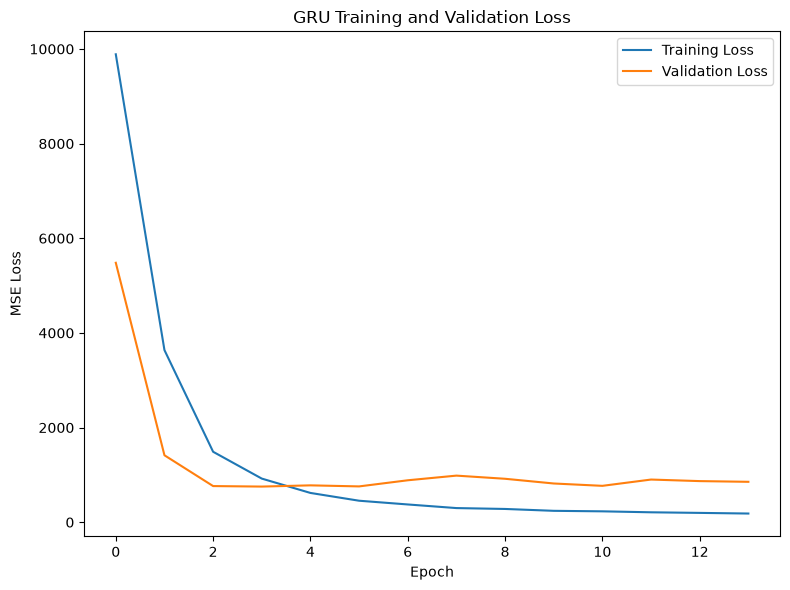

In [11]:
plt.figure(figsize=(8, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GRU Training and Validation Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/feature_engineered/stack_gru/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

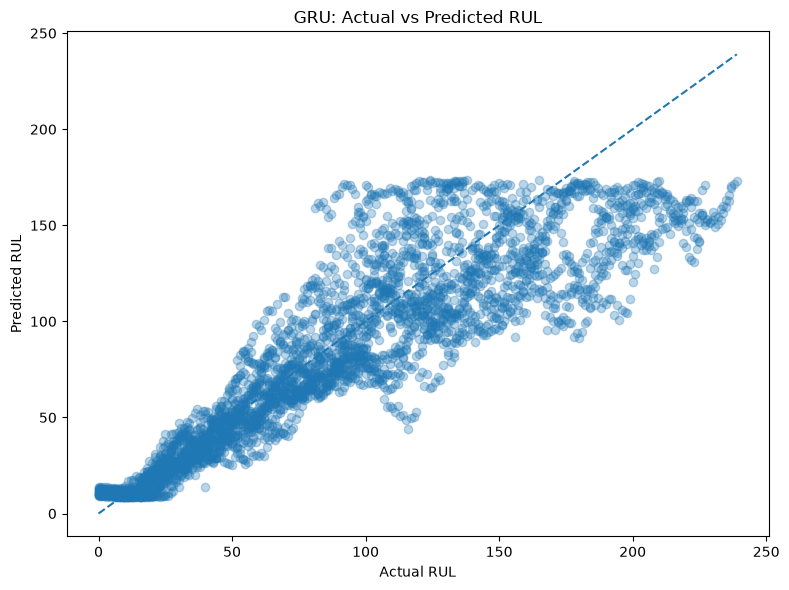

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_val_seq,
    y_pred,
    alpha=0.3
)

plt.plot(
    [y_val_seq.min(), y_val_seq.max()],
    [y_val_seq.min(), y_val_seq.max()],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("GRU: Actual vs Predicted RUL")

plt.tight_layout()

plt.savefig(
    "../results/figures/feature_engineered/stack_gru/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

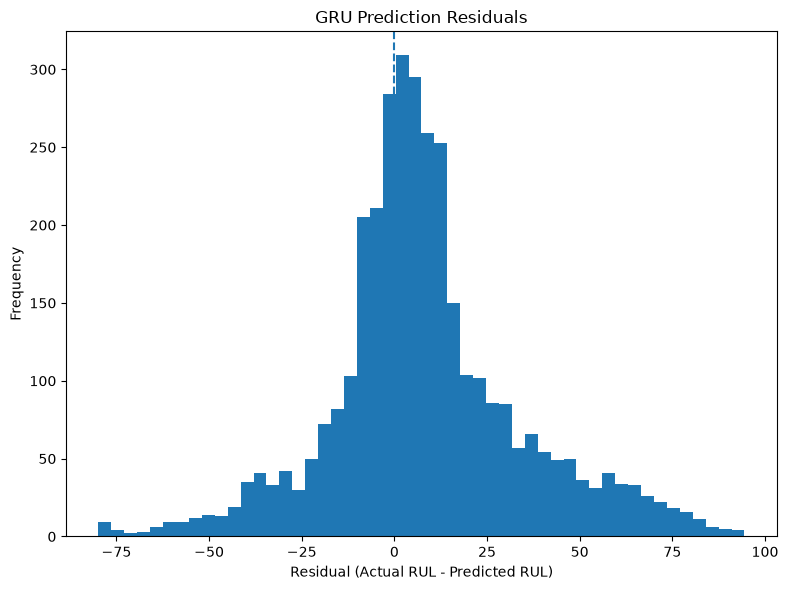

In [17]:
residuals = y_val_seq - y_pred
plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual (Actual RUL - Predicted RUL)")
plt.ylabel("Frequency")
plt.title("GRU Prediction Residuals")

plt.tight_layout()

plt.savefig(
    "../results/figures/feature_engineered/stack_gru/residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
y_pred = model.predict(
    X_val_seq
).flatten()

110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


In [16]:
mae = mean_absolute_error(y_val_seq, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_seq, y_pred))
r2 = r2_score(y_val_seq, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


MAE: 19.5721
RMSE: 27.4521
R²: 0.7779


In [22]:
metrics = pd.DataFrame({
    "model": ["GRU Feature-Engineered"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

metrics.to_csv(
    "../results/metrics/stacked_gru_feature_engineered_metrics.csv",
    index=False
)

In [21]:
model.save(
    "../models/gru_feature_engineered_scaled.keras"
)